In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

print("✅ All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✅ All libraries imported successfully!
Pandas version: 3.0.0
NumPy version: 2.4.2


In [3]:
# Load all datasets
ratings = pd.read_csv('../data/ml-latest-small/ratings.csv')
movies = pd.read_csv('../data/ml-latest-small/movies.csv')
tags = pd.read_csv('../data/ml-latest-small/tags.csv')
links = pd.read_csv('../data/ml-latest-small/links.csv')

print("✅ Data loaded successfully!\n")
print(f"Ratings shape: {ratings.shape}")
print(f"Movies shape: {movies.shape}")
print(f"Tags shape: {tags.shape}")
print(f"Links shape: {links.shape}")

✅ Data loaded successfully!

Ratings shape: (100836, 4)
Movies shape: (9742, 3)
Tags shape: (3683, 4)
Links shape: (9742, 3)


In [4]:
print("="*70)
print("DATASET STATISTICS")
print("="*70)
print(f"Number of unique users: {ratings['userId'].nunique()}")
print(f"Number of unique movies: {ratings['movieId'].nunique()}")
print(f"Total number of ratings: {len(ratings):,}")
print(f"Rating range: {ratings['rating'].min()} to {ratings['rating'].max()}")
print(f"Average rating: {ratings['rating'].mean():.2f}")
print(f"Median rating: {ratings['rating'].median():.2f}")

# Calculate sparsity
total_possible_ratings = ratings['userId'].nunique() * ratings['movieId'].nunique()
sparsity = 1 - (len(ratings) / total_possible_ratings)
print(f"\nSparsity: {sparsity:.4f} ({sparsity*100:.2f}%)")
print(f"Coverage: {(1-sparsity)*100:.2f}%")

DATASET STATISTICS
Number of unique users: 610
Number of unique movies: 9724
Total number of ratings: 100,836
Rating range: 0.5 to 5.0
Average rating: 3.50
Median rating: 3.50

Sparsity: 0.9830 (98.30%)
Coverage: 1.70%


In [5]:
print("\n" + "="*70)
print("SAMPLE RATINGS DATA")
print("="*70)
print(ratings.head(10))

print("\n" + "="*70)
print("SAMPLE MOVIES DATA")
print("="*70)
print(movies.head(10))


SAMPLE RATINGS DATA
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
5       1       70     3.0  964982400
6       1      101     5.0  964980868
7       1      110     4.0  964982176
8       1      151     5.0  964984041
9       1      157     5.0  964984100

SAMPLE MOVIES DATA
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   
5        6                         Heat (1995)   
6        7                      Sabrina (1995)   
7        8                 Tom and Huck (1995)   
8        9                 Sudden Death (1995)   
9       10                    GoldenEye (

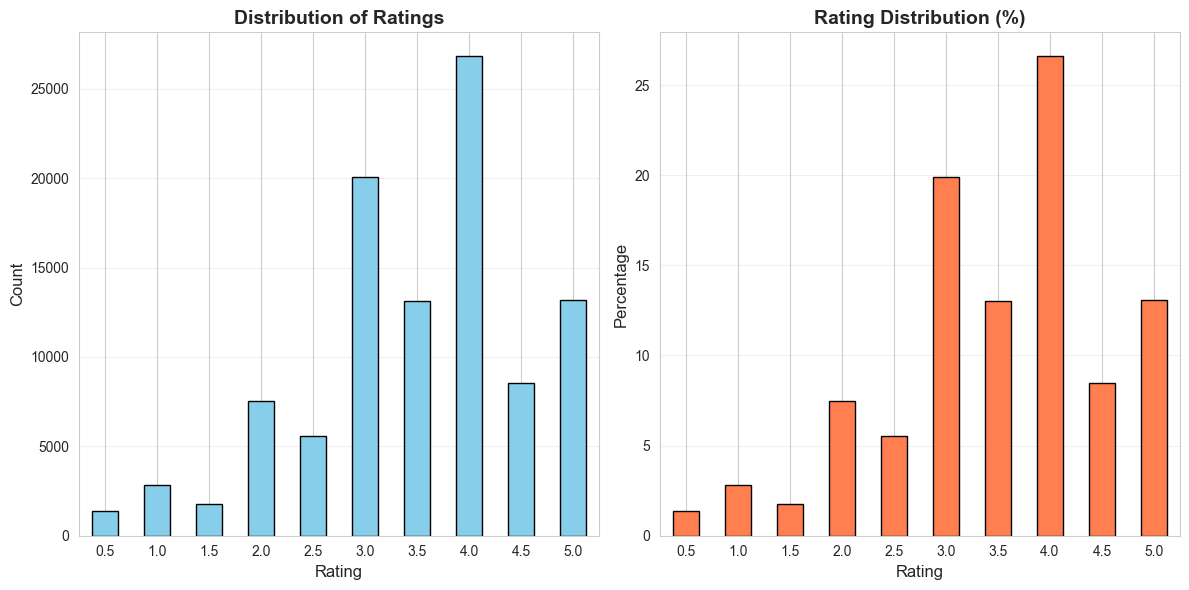


✅ Most common rating: 4.0
✅ Median rating: 3.5

Rating Distribution:
rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211


In [6]:
# Rating distribution visualization
plt.figure(figsize=(12, 6))

# Count plot
rating_counts = ratings['rating'].value_counts().sort_index()
plt.subplot(1, 2, 1)
rating_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Ratings', fontsize=14, fontweight='bold')
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Percentage plot
plt.subplot(1, 2, 2)
rating_pct = (rating_counts / rating_counts.sum() * 100)
rating_pct.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Rating Distribution (%)', fontsize=14, fontweight='bold')
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Percentage', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Most common rating: {ratings['rating'].mode()[0]}")
print(f"✅ Median rating: {ratings['rating'].median()}")
print("\nRating Distribution:")
print(rating_counts.to_string())

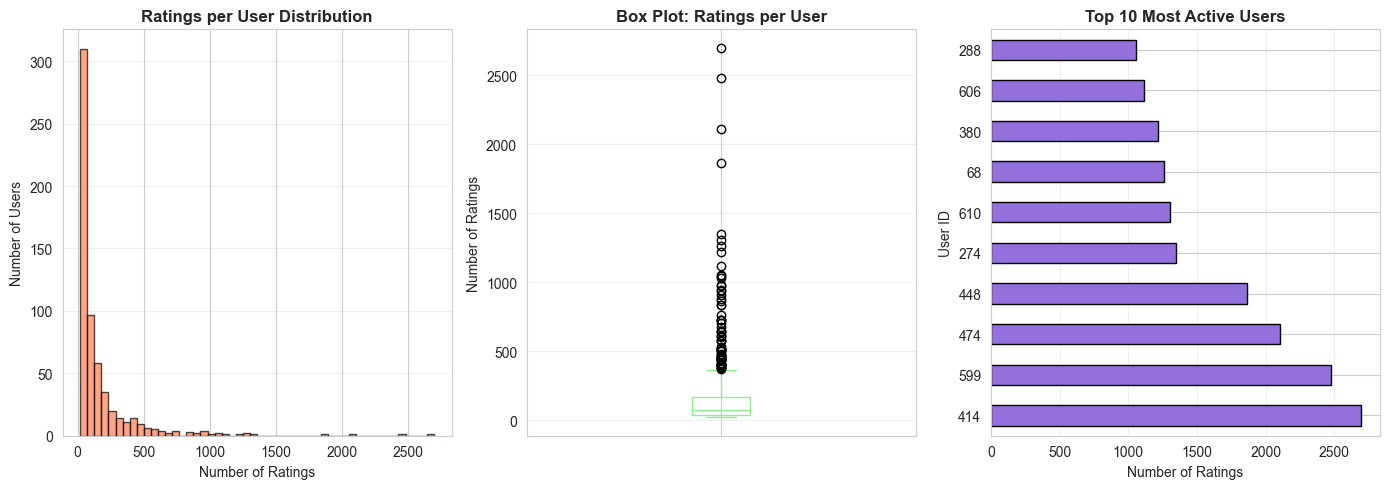


✅ Average ratings per user: 165.30
✅ Median ratings per user: 70
✅ Max ratings by a user: 2698
✅ Min ratings by a user: 20
✅ Users with >100 ratings: 245


In [7]:
# Ratings per user
user_rating_counts = ratings.groupby('userId').size()

plt.figure(figsize=(14, 5))

# Histogram
plt.subplot(1, 3, 1)
user_rating_counts.hist(bins=50, color='coral', edgecolor='black', alpha=0.7)
plt.title('Ratings per User Distribution', fontweight='bold')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')
plt.grid(axis='y', alpha=0.3)

# Box plot
plt.subplot(1, 3, 2)
user_rating_counts.plot(kind='box', color='lightgreen')
plt.title('Box Plot: Ratings per User', fontweight='bold')
plt.ylabel('Number of Ratings')
plt.grid(axis='y', alpha=0.3)

# Top users
plt.subplot(1, 3, 3)
top_users = user_rating_counts.nlargest(10)
top_users.plot(kind='barh', color='mediumpurple', edgecolor='black')
plt.title('Top 10 Most Active Users', fontweight='bold')
plt.xlabel('Number of Ratings')
plt.ylabel('User ID')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Average ratings per user: {user_rating_counts.mean():.2f}")
print(f"✅ Median ratings per user: {user_rating_counts.median():.0f}")
print(f"✅ Max ratings by a user: {user_rating_counts.max()}")
print(f"✅ Min ratings by a user: {user_rating_counts.min()}")
print(f"✅ Users with >100 ratings: {(user_rating_counts > 100).sum()}")

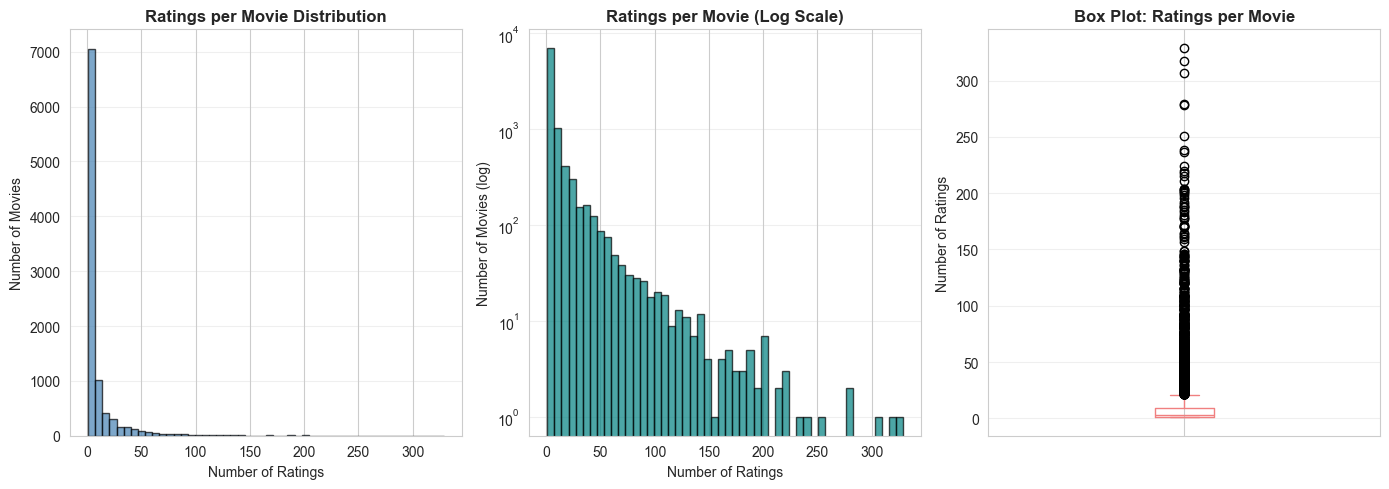


✅ Average ratings per movie: 10.37
✅ Median ratings per movie: 3
✅ Movies with only 1 rating: 3446
✅ Movies with >100 ratings: 134


In [8]:
# Ratings per movie
movie_rating_counts = ratings.groupby('movieId').size()

plt.figure(figsize=(14, 5))

# Histogram
plt.subplot(1, 3, 1)
movie_rating_counts.hist(bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Ratings per Movie Distribution', fontweight='bold')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Movies')
plt.grid(axis='y', alpha=0.3)

# Log scale
plt.subplot(1, 3, 2)
plt.hist(movie_rating_counts, bins=50, color='teal', edgecolor='black', alpha=0.7)
plt.yscale('log')
plt.title('Ratings per Movie (Log Scale)', fontweight='bold')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Movies (log)')
plt.grid(axis='y', alpha=0.3)

# Box plot
plt.subplot(1, 3, 3)
movie_rating_counts.plot(kind='box', color='lightcoral')
plt.title('Box Plot: Ratings per Movie', fontweight='bold')
plt.ylabel('Number of Ratings')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Average ratings per movie: {movie_rating_counts.mean():.2f}")
print(f"✅ Median ratings per movie: {movie_rating_counts.median():.0f}")
print(f"✅ Movies with only 1 rating: {(movie_rating_counts == 1).sum()}")
print(f"✅ Movies with >100 ratings: {(movie_rating_counts > 100).sum()}")


TOP 20 MOST RATED MOVIES
                                                                                  title  rating_count  avg_rating
movieId                                                                                                          
356                                                                 Forrest Gump (1994)           329    4.164134
318                                                    Shawshank Redemption, The (1994)           317    4.429022
296                                                                 Pulp Fiction (1994)           307    4.197068
593                                                    Silence of the Lambs, The (1991)           279    4.161290
2571                                                                 Matrix, The (1999)           278    4.192446
260                                           Star Wars: Episode IV - A New Hope (1977)           251    4.231076
480                                                           

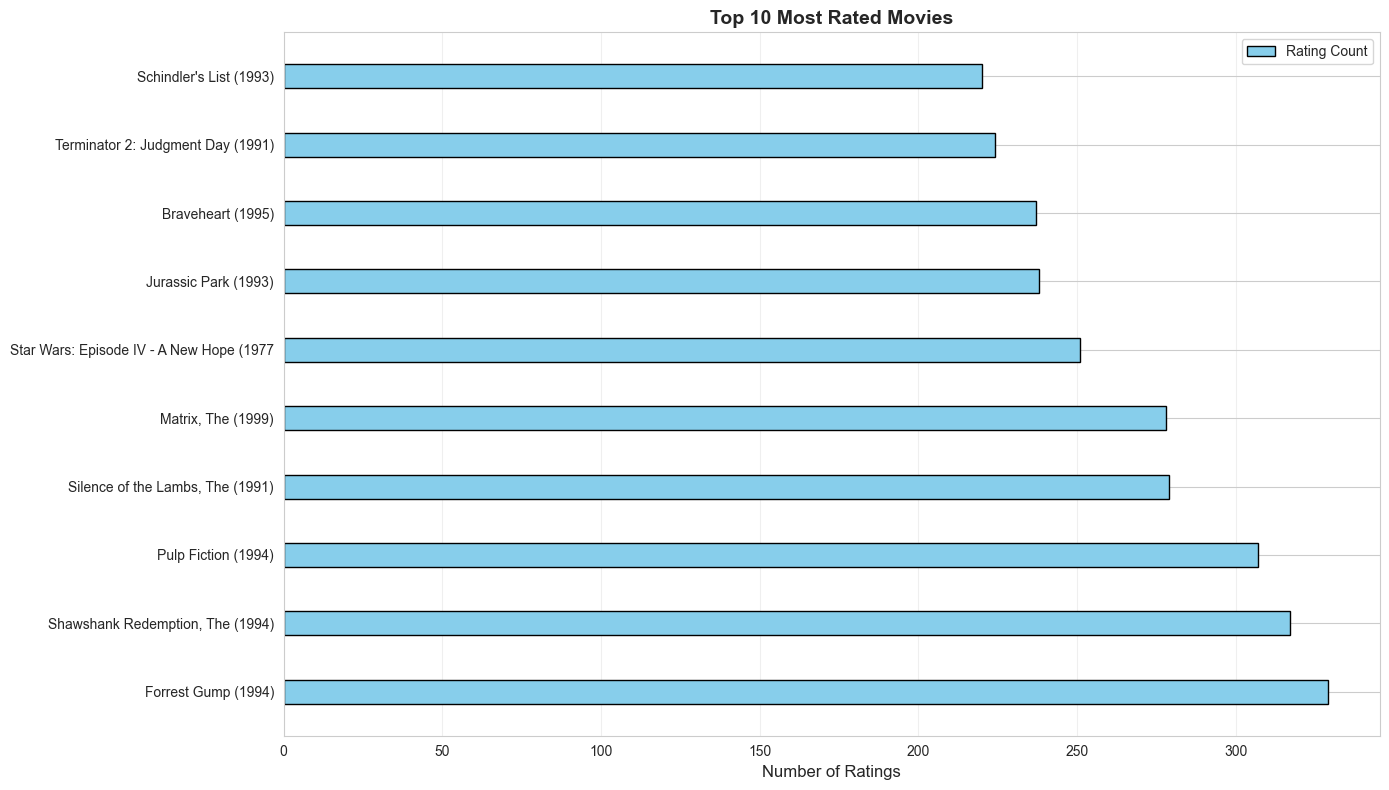

In [9]:
# Get most rated movies
most_rated = ratings.groupby('movieId').size().sort_values(ascending=False).head(20)
most_rated_movies = movies[movies['movieId'].isin(most_rated.index)].set_index('movieId')
most_rated_movies['rating_count'] = most_rated

# Also get average ratings for these movies
avg_ratings = ratings[ratings['movieId'].isin(most_rated.index)].groupby('movieId')['rating'].mean()
most_rated_movies['avg_rating'] = avg_ratings

# Sort by rating count
most_rated_movies = most_rated_movies.sort_values('rating_count', ascending=False)

print("\n" + "="*70)
print("TOP 20 MOST RATED MOVIES")
print("="*70)
print(most_rated_movies[['title', 'rating_count', 'avg_rating']].to_string())

# Visualize
plt.figure(figsize=(14, 8))
top_10 = most_rated_movies.head(10)
x = range(len(top_10))
width = 0.35

plt.barh(x, top_10['rating_count'], height=width, label='Rating Count', color='skyblue', edgecolor='black')
plt.yticks(x, top_10['title'].str[:40])  # Truncate long titles
plt.xlabel('Number of Ratings', fontsize=12)
plt.title('Top 10 Most Rated Movies', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


✅ Total unique genres: 19

Genre Distribution:
Drama          4361
Comedy         3756
Thriller       1894
Action         1828
Romance        1596
Adventure      1263
Crime          1199
Sci-Fi          980
Horror          978
Fantasy         779
Children        664
Animation       611
Mystery         573
Documentary     440
War             382
Musical         334
Western         167
IMAX            158
Film-Noir        87


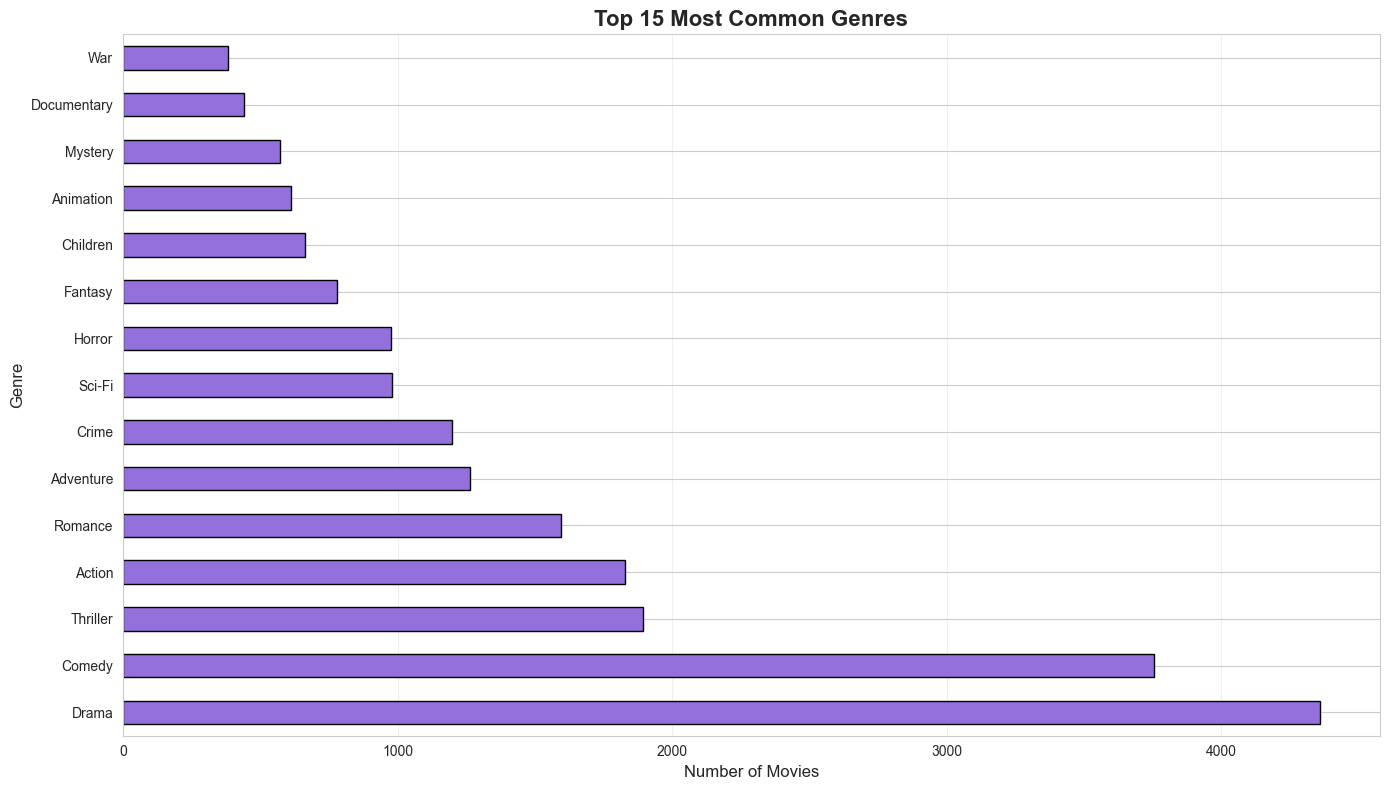


✅ Most common genre: Drama (4361 movies)


In [11]:
# Split genres and count them
all_genres = movies['genres'].str.split('|', expand=True).stack()
genre_counts = all_genres.value_counts()

# Remove "(no genres listed)"
genre_counts = genre_counts[genre_counts.index != '(no genres listed)']

print(f"\n✅ Total unique genres: {len(genre_counts)}")
print(f"\nGenre Distribution:")
print(genre_counts.to_string())

# Visualize
plt.figure(figsize=(14, 8))
genre_counts.head(15).plot(kind='barh', color='mediumpurple', edgecolor='black')
plt.title('Top 15 Most Common Genres', fontsize=16, fontweight='bold')
plt.xlabel('Number of Movies', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✅ Most common genre: {genre_counts.index[0]} ({genre_counts.iloc[0]} movies)")


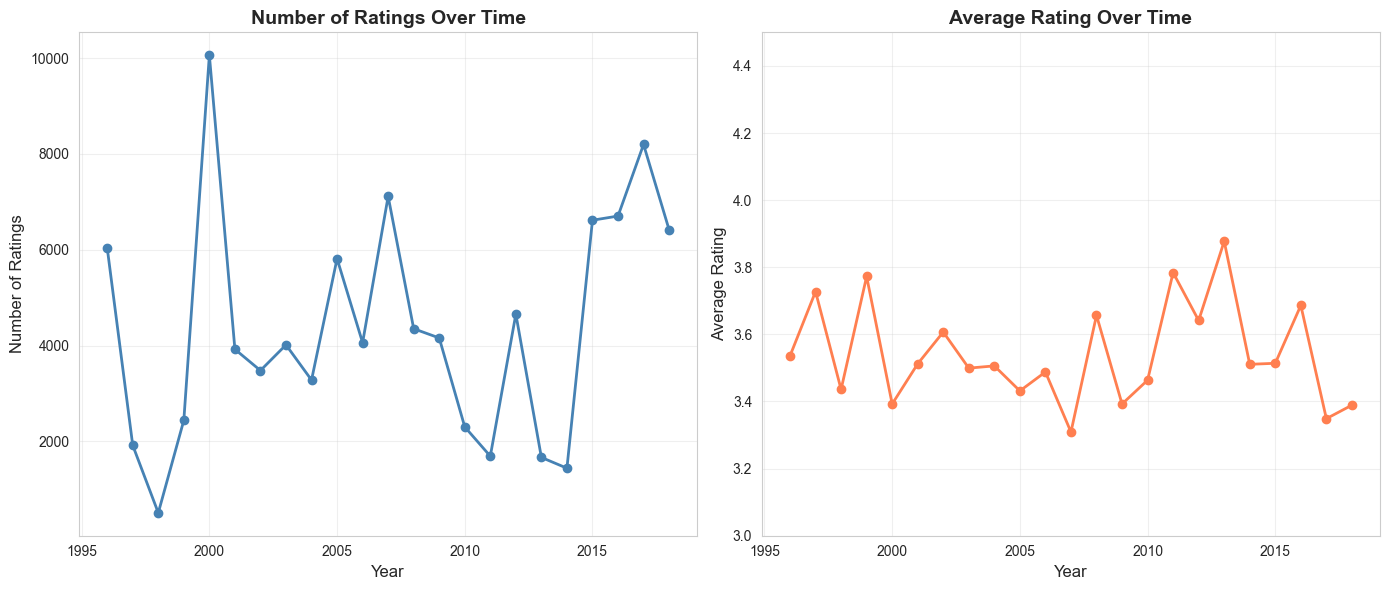


✅ Earliest rating: 1996-03-29 18:36:55
✅ Latest rating: 2018-09-24 14:27:30
✅ Time span: 8213 days


In [12]:
# Convert timestamp to datetime
ratings['datetime'] = pd.to_datetime(ratings['timestamp'], unit='s')
ratings['year'] = ratings['datetime'].dt.year
ratings['month'] = ratings['datetime'].dt.month

# Ratings over time
ratings_by_year = ratings.groupby('year').size()

plt.figure(figsize=(14, 6))

# Ratings per year
plt.subplot(1, 2, 1)
ratings_by_year.plot(kind='line', marker='o', color='steelblue', linewidth=2)
plt.title('Number of Ratings Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Ratings', fontsize=12)
plt.grid(alpha=0.3)

# Average rating over time
avg_rating_by_year = ratings.groupby('year')['rating'].mean()
plt.subplot(1, 2, 2)
avg_rating_by_year.plot(kind='line', marker='o', color='coral', linewidth=2)
plt.title('Average Rating Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.ylim(3, 4.5)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Earliest rating: {ratings['datetime'].min()}")
print(f"✅ Latest rating: {ratings['datetime'].max()}")
print(f"✅ Time span: {(ratings['datetime'].max() - ratings['datetime'].min()).days} days")

In [13]:
print("\n" + "="*70)
print("DATA QUALITY CHECK")
print("="*70)

# Check for missing values
print("\nMissing Values:")
print(f"Ratings: {ratings.isnull().sum().sum()}")
print(f"Movies: {movies.isnull().sum().sum()}")

# Check for duplicates
print(f"\nDuplicate ratings: {ratings.duplicated().sum()}")
print(f"Duplicate movies: {movies.duplicated().sum()}")

# Check rating range
invalid_ratings = ratings[(ratings['rating'] < 0.5) | (ratings['rating'] > 5)]
print(f"\nInvalid ratings (outside 0.5-5 range): {len(invalid_ratings)}")

print("\n✅ Data quality looks good!")


DATA QUALITY CHECK

Missing Values:
Ratings: 0
Movies: 0

Duplicate ratings: 0
Duplicate movies: 0

Invalid ratings (outside 0.5-5 range): 0

✅ Data quality looks good!


In [14]:
import os

# Create processed directory
os.makedirs('../data/processed', exist_ok=True)

# Save cleaned data
ratings.to_csv('../data/processed/ratings_clean.csv', index=False)
movies.to_csv('../data/processed/movies_clean.csv', index=False)
tags.to_csv('../data/processed/tags_clean.csv', index=False)
links.to_csv('../data/processed/links_clean.csv', index=False)

print("\n" + "="*70)
print("✅ DATA EXPLORATION COMPLETE!")
print("="*70)
print("\nFiles saved to: data/processed/")
print("\nDataset Summary:")
print(f"  • {ratings['userId'].nunique()} users")
print(f"  • {ratings['movieId'].nunique()} movies")
print(f"  • {len(ratings):,} ratings")
print(f"  • {len(genre_counts)} genres")
print(f"  • Average rating: {ratings['rating'].mean():.2f}")
print(f"  • Sparsity: {sparsity*100:.2f}%")
print("\n" + "="*70)
print("NEXT STEPS:")
print("="*70)
print("1. Create notebook: 02_collaborative_filtering.ipynb")
print("2. Implement SVD algorithm")
print("3. Train and evaluate model")
print("4. Compare different algorithms")
print("="*70)


✅ DATA EXPLORATION COMPLETE!

Files saved to: data/processed/

Dataset Summary:
  • 610 users
  • 9724 movies
  • 100,836 ratings
  • 19 genres
  • Average rating: 3.50
  • Sparsity: 98.30%

NEXT STEPS:
1. Create notebook: 02_collaborative_filtering.ipynb
2. Implement SVD algorithm
3. Train and evaluate model
4. Compare different algorithms
